<a href="https://colab.research.google.com/github/NidhiBorasia103/Acedemic-Projects/blob/main/Assignment1_MLP_vs_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comparing MLP and CNN for Image Classification

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import fashion_mnist

## 1. Dataset and Preprocessing

Here I am using the Fashion-MNIST dataset as mentioned.
Fashion-MNIST contains grayscale images of clothing items.

The dataset is loaded and the pixel values are normalized from the original range of 0–255 to 0–1.

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


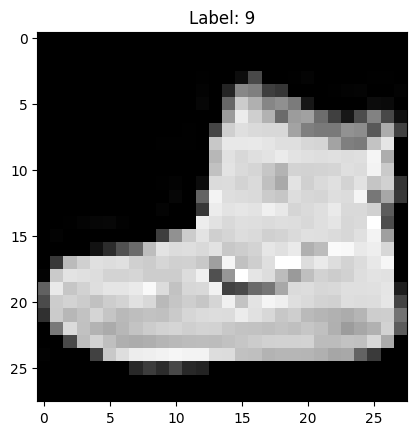

In [ ]:
plt.imshow(x_train[0], cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

In [ ]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 2. MLP Model

The MLP first flattens each 28 × 28 image into a one-dimensional vector of 784 pixel values. It then uses two fully connected hidden layers with ReLU activation. The output layer contains 10 neurons with softmax activation for the 10 Fashion-MNIST classes.

**Architecture:** Flatten → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)

In [ ]:
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
start_time = time.time()

mlp_history = mlp_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

mlp_training_time = time.time() - start_time

print("MLP Training Time:", mlp_training_time, "seconds")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8061 - loss: 0.5587 - val_accuracy: 0.8458 - val_loss: 0.4169
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8594 - loss: 0.3945 - val_accuracy: 0.8595 - val_loss: 0.3901
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8700 - loss: 0.3604 - val_accuracy: 0.8717 - val_loss: 0.3608
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8820 - loss: 0.3251 - val_accuracy: 0.8763 - val_loss: 0.3608
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8867 - loss: 0.3118 - val_accuracy: 0.8747 - val_loss: 0.3543
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8915 - loss: 0.2960 - val_accuracy: 0.8842 - val_loss: 0.3251
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8965 - loss: 0.2826 - val_accuracy: 0.8828 - val_loss: 0.3248
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9000 - loss: 0.2699 - val_accuracy: 0.

In [ ]:
mlp_test_loss, mlp_test_accuracy = mlp_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("MLP Test Accuracy:", mlp_test_accuracy)
print("MLP Test Loss:", mlp_test_loss)

MLP Test Accuracy: 0.8834999799728394
MLP Test Loss: 0.33043429255485535


In [ ]:
mlp_train_accuracy = mlp_history.history['accuracy'][-1]
mlp_train_loss = mlp_history.history['loss'][-1]
mlp_parameters = mlp_model.count_params()

print("MLP Training Accuracy:", mlp_train_accuracy)
print("MLP Training Loss:", mlp_train_loss)
print("MLP Test Accuracy:", mlp_test_accuracy)
print("MLP Test Loss:", mlp_test_loss)
print("MLP Parameters:", mlp_parameters)
print("MLP Training Time:", mlp_training_time, "seconds")

MLP Training Accuracy: 0.9076111316680908
MLP Training Loss: 0.24964825809001923
MLP Test Accuracy: 0.8834999799728394
MLP Test Loss: 0.33043429255485535
MLP Parameters: 109386
MLP Training Time: 16.933793783187866 seconds


In [ ]:
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_test_cnn = np.expand_dims(x_test, axis=-1)

print("CNN training shape:", x_train_cnn.shape)
print("CNN test shape:", x_test_cnn.shape)

CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


## 3. CNN Model

The CNN processes the images while preserving their spatial structure. It uses convolutional layers to learn local image features and max-pooling layers to reduce the spatial dimensions.

**Architecture:** Conv2D(32, 3×3) → MaxPooling(2×2) → Conv2D(64, 3×3) → MaxPooling(2×2) → Flatten → Dense(64, ReLU) → Dense(10, Softmax)

In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
start_time = time.time()

cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

cnn_training_time = time.time() - start_time

print("CNN Training Time:", cnn_training_time, "seconds")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7844 - loss: 0.6056 - val_accuracy: 0.8488 - val_loss: 0.4255
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8628 - loss: 0.3845 - val_accuracy: 0.8727 - val_loss: 0.3591
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8809 - loss: 0.3372 - val_accuracy: 0.8747 - val_loss: 0.3415
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8918 - loss: 0.3049 - val_accuracy: 0.8933 - val_loss: 0.2974
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8972 - loss: 0.2837 - val_accuracy: 0.9000 - val_loss: 0.2851
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9045 - loss: 0.2644 - val_accuracy: 0.8975 - val_loss: 0.2827
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9101 - loss: 0.2468 - val_accuracy: 0.9015 - val_loss: 0.2741
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9172 - loss: 0.2311 - val_accuracy: 0

In [ ]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)

print("CNN Test Accuracy:", cnn_test_accuracy)
print("CNN Test Loss:", cnn_test_loss)

CNN Test Accuracy: 0.902999997138977
CNN Test Loss: 0.2736666202545166


In [ ]:
cnn_train_accuracy = cnn_history.history['accuracy'][-1]
cnn_train_loss = cnn_history.history['loss'][-1]
cnn_parameters = cnn_model.count_params()

print("CNN Training Accuracy:", cnn_train_accuracy)
print("CNN Training Loss:", cnn_train_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)
print("CNN Test Loss:", cnn_test_loss)
print("CNN Parameters:", cnn_parameters)
print("CNN Training Time:", cnn_training_time, "seconds")

CNN Training Accuracy: 0.9244258999824524
CNN Training Loss: 0.2062157690525055
CNN Test Accuracy: 0.902999997138977
CNN Test Loss: 0.2736666202545166
CNN Parameters: 121930
CNN Training Time: 24.861161947250366 seconds


## 4. Experimental Results

Both models were trained using the same Fashion-MNIST training/test split. The Adam optimizer, sparse categorical cross-entropy loss, batch size of 128, and 10 training epochs were used for both models.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["MLP", "CNN"],
    "Training Accuracy": [
        f"{mlp_train_accuracy * 100:.2f}%",
        f"{cnn_train_accuracy * 100:.2f}%"
    ],
    "Test Accuracy": [
        f"{mlp_test_accuracy * 100:.2f}%",
        f"{cnn_test_accuracy * 100:.2f}%"
    ],
    "Training Loss": [
        f"{mlp_train_loss:.4f}",
        f"{cnn_train_loss:.4f}"
    ],
    "Parameters": [
        mlp_parameters,
        cnn_parameters
    ],
    "Training Time (s)": [
        f"{mlp_training_time:.2f}",
        f"{cnn_training_time:.2f}"
    ]
})

results

,Model,Training Accuracy,Test Accuracy,Training Loss,Parameters,Training Time (s)
0,MLP,90.76%,88.35%,0.2496,109386,16.93
1,CNN,92.44%,90.30%,0.2062,121930,24.86


## 5. Training Accuracy and Loss

The following graphs compare the training accuracy and training loss of the MLP and CNN across 10 epochs.

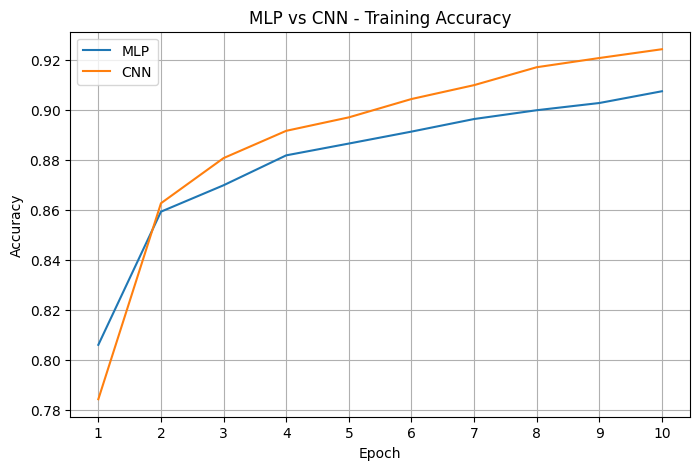

In [ ]:
epochs = range(1, 11)

plt.figure(figsize=(8, 5))

plt.plot(epochs, mlp_history.history['accuracy'], label='MLP')
plt.plot(epochs, cnn_history.history['accuracy'], label='CNN')

plt.title('MLP vs CNN - Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

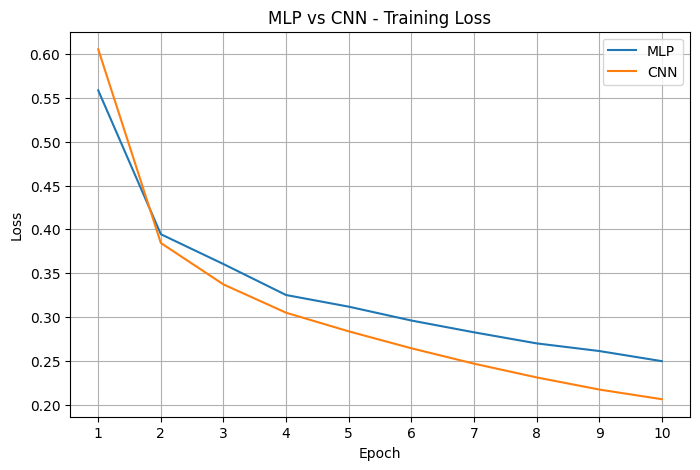

In [ ]:
epochs = range(1, 11)

plt.figure(figsize=(8, 5))

plt.plot(epochs, mlp_history.history['loss'], label='MLP')
plt.plot(epochs, cnn_history.history['loss'], label='CNN')

plt.title('MLP vs CNN - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

## 6. Summary

The CNN achieved higher training and test accuracy than the MLP in this experiment. The CNN achieved 90.30% test accuracy compared with 88.35% for the MLP. However, the CNN also required more trainable parameters and a longer training time.

From my results, I noticed that the CNN took longer to train, but its test accuracy was about 2% higher than the MLP. I think this happened because the CNN keeps the image structure while learning features, whereas the MLP first flattens the image

From the accuracy graph, I noticed that both models improved over the 10 epochs, but the CNN finished with higher training accuracy. The loss graph also shows that the CNN ended with a lower training loss

The accuracy and loss graphs show that both models improved during training. Overall, the CNN provided better classification performance on Fashion-MNIST, while the MLP was simpler and faster to train.

A detailed comparison and discussion of the architectural differences between the two models is provided in the accompanying report.

I think this is why the CNN performed better in my experiment. It can look for features in different parts of an image, while the MLP first changes the image into a flat list of pixels.